# Analyse de la Consommation Énergétique

Ce notebook présente une analyse complète des données de consommation énergétique, incluant l'exploration des données, la visualisation des tendances, et l'évaluation du modèle de prédiction.

In [34]:
# Import des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import os

# Configuration du style des graphiques

sns.set_theme(style="whitegrid")  # ou un autre style comme "darkgrid", "white", etc.

sns.set_palette("husl")

# Configuration pour afficher tous les résultats
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## 1. Chargement et Exploration des Données

In [35]:
# Chargement des données
data_path = '../data/processed/energy_data_processed.csv'
df = pd.read_csv(data_path)

# Affichage des premières lignes
print("Aperçu des données :")
display(df.head())

# Informations sur le dataset
print("\nInformations sur le dataset :")
display(df.info())

# Statistiques descriptives
print("\nStatistiques descriptives :")
display(df.describe())

Aperçu des données :


,temperature,humidite,vitesse_vent,precipitation,mois,jour_semaine,weekend,evenement,consommation
0,2.088043,59.518974,13.614730,15.590447,7,3,0,1,462600.0
1,34.472939,62.990087,12.074847,4.407106,7,4,0,0,424376.0
2,24.268472,72.533822,10.978327,15.971127,7,5,1,1,396572.0
3,-2.854022,55.637400,3.927900,8.577358,7,6,1,0,422882.0
4,-2.689794,49.096333,25.518186,4.414460,7,0,0,0,507533.0



Informations sur le dataset :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2155 entries, 0 to 2154
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   temperature    2155 non-null   float64
 1   humidite       2155 non-null   float64
 2   vitesse_vent   2155 non-null   float64
 3   precipitation  2155 non-null   float64
 4   mois           2155 non-null   int64  
 5   jour_semaine   2155 non-null   int64  
 6   weekend        2155 non-null   int64  
 7   evenement      2155 non-null   int64  
 8   consommation   2155 non-null   float64
dtypes: float64(5), int64(4)
memory usage: 151.7 KB


None


Statistiques descriptives :


,temperature,humidite,vitesse_vent,precipitation,mois,jour_semaine,weekend,evenement,consommation
count,2155.000000,2155.000000,2155.000000,2155.000000,2155.000000,2155.000000,2155.000000,2155.000000,2155.000000
mean,14.592556,59.569789,14.976853,9.958826,6.798144,3.029698,0.290951,0.415777,433082.458469
std,14.337980,17.369171,8.561004,5.808780,3.507863,2.001172,0.454307,0.492970,60351.984288
min,-9.993603,30.037874,0.017159,0.027690,1.000000,0.000000,0.000000,0.000000,308035.000000
25%,2.246410,44.571741,7.536397,4.835280,4.000000,1.000000,0.000000,0.000000,391422.000000
50%,15.319006,59.946278,14.690694,9.974073,7.000000,3.000000,0.000000,0.000000,419431.000000
75%,26.473600,74.225353,22.262669,15.200697,10.000000,5.000000,1.000000,1.000000,462927.000000
max,39.974092,89.995903,29.997219,19.968734,12.000000,6.000000,1.000000,1.000000,651367.000000


## 2. Analyse des Tendances

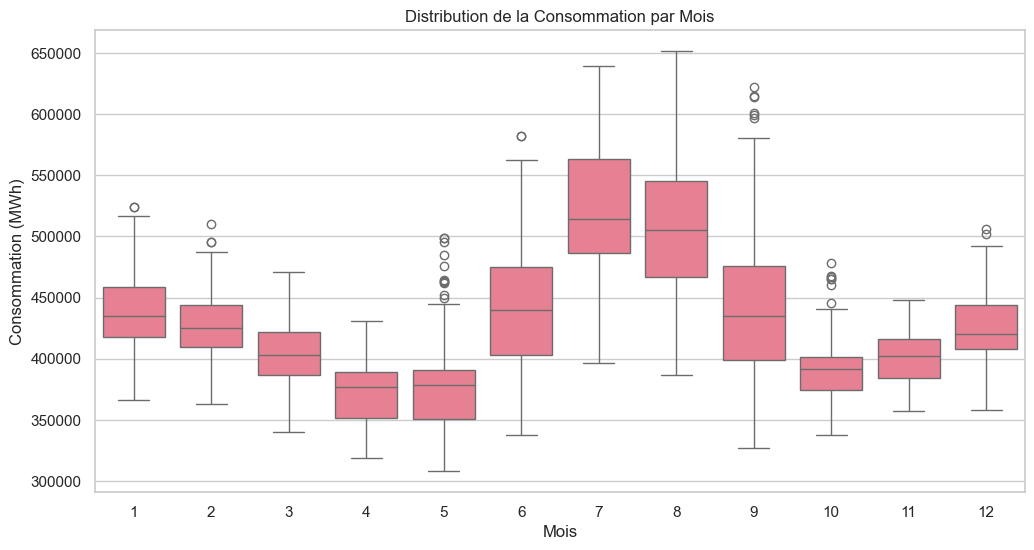

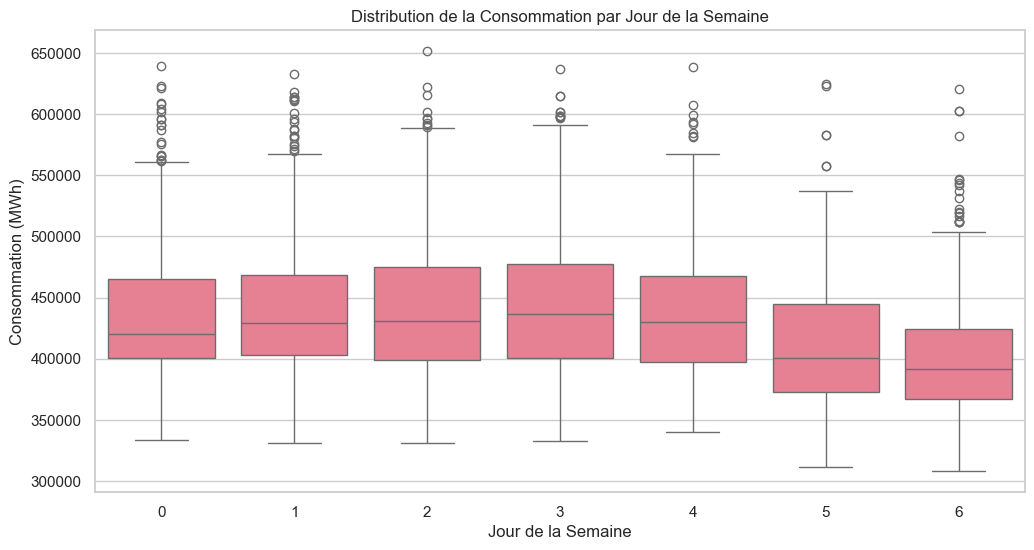

In [36]:
# Création d'un graphique de tendance mensuelle
plt.figure(figsize=(12, 6))
sns.boxplot(x='mois', y='consommation', data=df)
plt.title('Distribution de la Consommation par Mois')
plt.xlabel('Mois')
plt.ylabel('Consommation (MWh)')
plt.show()

# Création d'un graphique de tendance hebdomadaire
plt.figure(figsize=(12, 6))
sns.boxplot(x='jour_semaine', y='consommation', data=df)
plt.title('Distribution de la Consommation par Jour de la Semaine')
plt.xlabel('Jour de la Semaine')
plt.ylabel('Consommation (MWh)')
plt.show()

## 3. Analyse des Corrélations

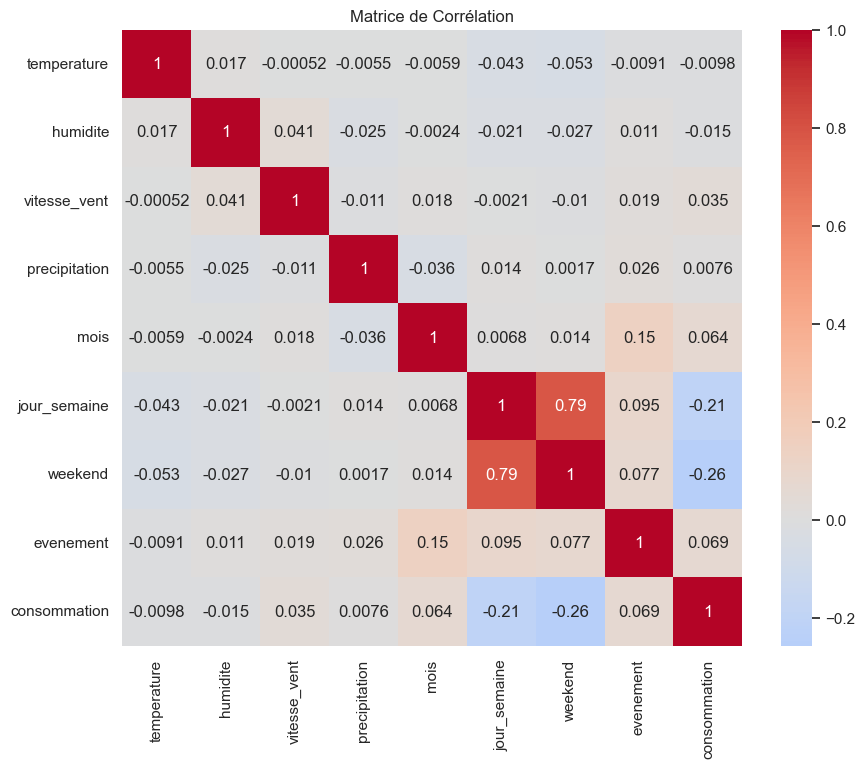

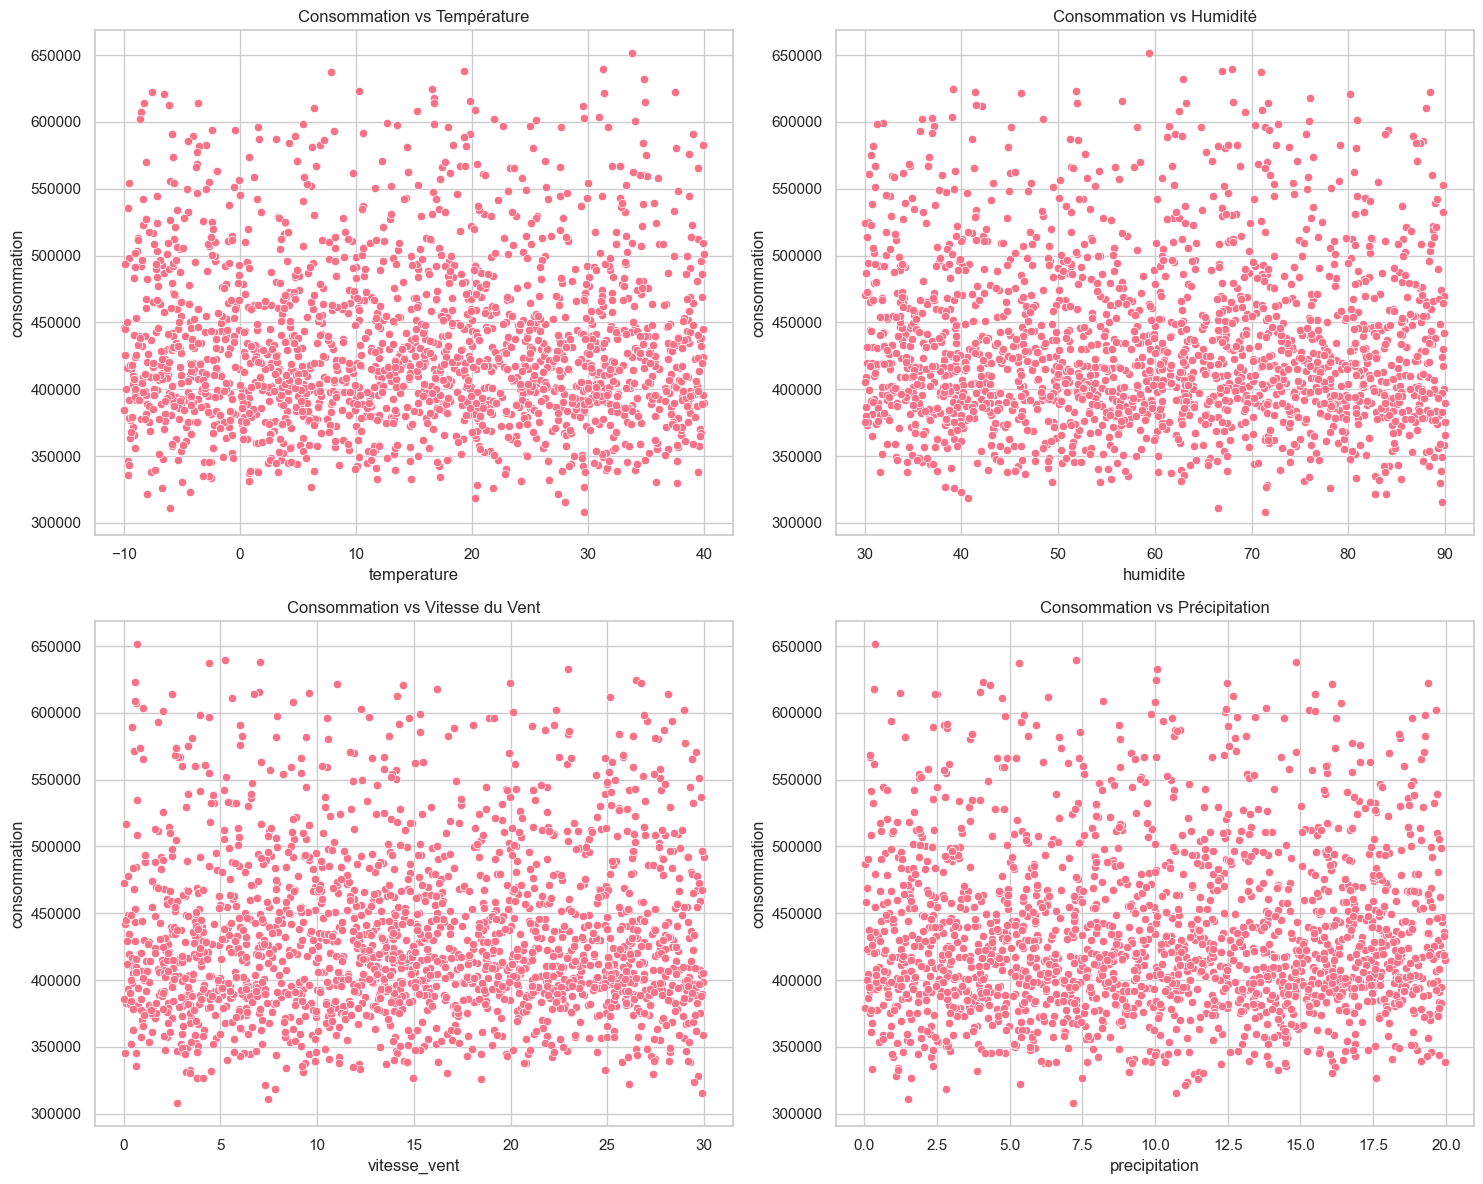

In [37]:
# Création de la matrice de corrélation
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Matrice de Corrélation')
plt.show()

# Création de scatter plots pour les variables les plus corrélées
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

sns.scatterplot(data=df, x='temperature', y='consommation', ax=axes[0,0])
axes[0,0].set_title('Consommation vs Température')

sns.scatterplot(data=df, x='humidite', y='consommation', ax=axes[0,1])
axes[0,1].set_title('Consommation vs Humidité')

sns.scatterplot(data=df, x='vitesse_vent', y='consommation', ax=axes[1,0])
axes[1,0].set_title('Consommation vs Vitesse du Vent')

sns.scatterplot(data=df, x='precipitation', y='consommation', ax=axes[1,1])
axes[1,1].set_title('Consommation vs Précipitation')

plt.tight_layout()
plt.show()

## 4. Évaluation du Modèle

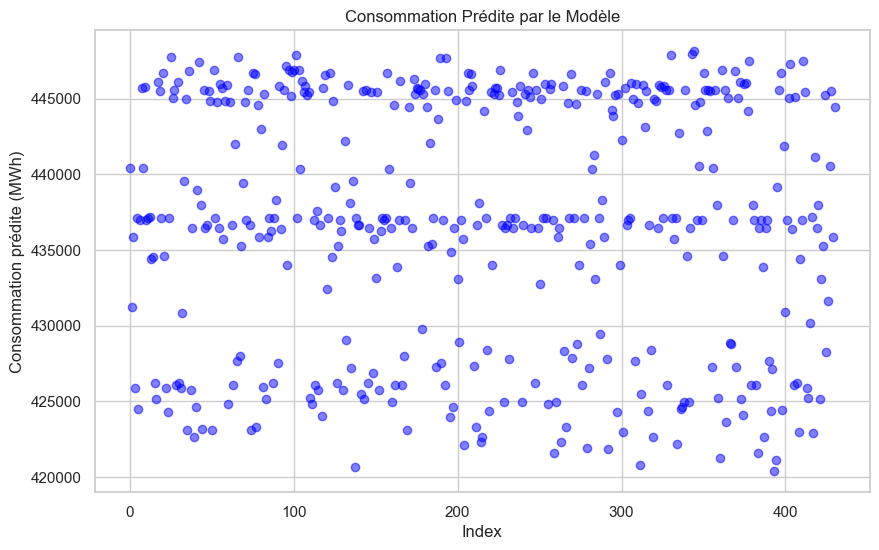

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

# Fonction pour charger les données sans la cible
def load_data_for_prediction():
    """
    Charge les données pour faire des prédictions uniquement (pas d'entraînement)
    """
    test_data = pd.read_csv('../data/processed/test_data.csv')

    # Supprimer la colonne 'consommation' si elle existe
    if 'consommation' in test_data.columns:
        test_data = test_data.drop(columns=['consommation'])

    # Gérer les valeurs manquantes
    test_data = test_data.fillna(test_data.mean())

    return test_data

# Chargement du modèle entraîné
model_path = '../models/best_model_20250402_145118.joblib'
model = joblib.load(model_path)

# Chargement des données à prédire
X_to_predict = load_data_for_prediction()

# Prédictions
y_pred = model.predict(X_to_predict)

# Visualisation des prédictions
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_pred)), y_pred, alpha=0.5, color='blue')
plt.xlabel('Index')
plt.ylabel('Consommation prédite (MWh)')
plt.title('Consommation Prédite par le Modèle')
plt.grid(True)
plt.show()


## 5. Importance des Features

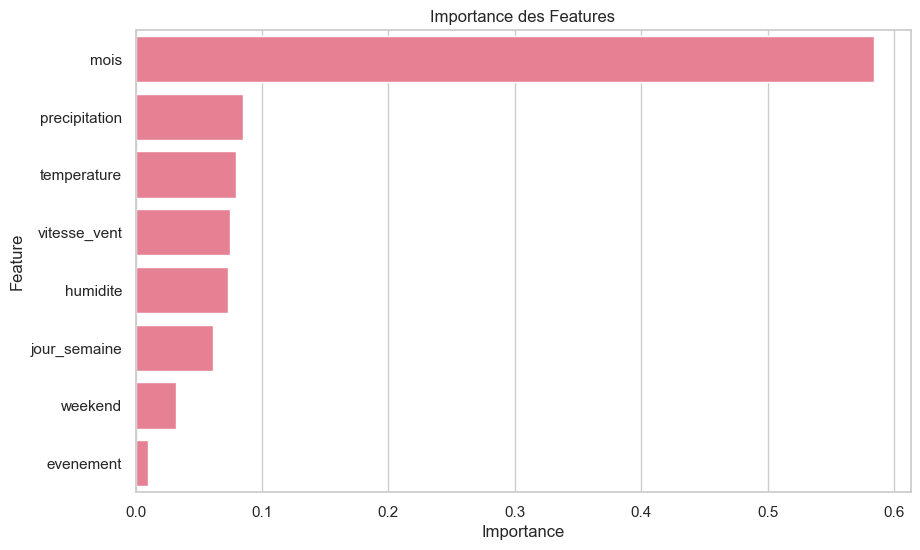

In [39]:
# Extraction de l'importance des features
feature_importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance': model.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)

# Visualisation de l'importance des features
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Importance des Features')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## 6. Conclusions

### Points Clés de l'Analyse :
1. **Tendances Saisonnières** :
   - La consommation varie significativement selon les mois
   - Les pics de consommation sont observés en hiver et en été
   - Les weekends montrent généralement une consommation plus faible

2. **Corrélations** :
   - La température est le facteur le plus influent sur la consommation
   - L'humidité montre une corrélation modérée
   - La vitesse du vent et les précipitations ont un impact plus faible

3. **Performance du Modèle** :
   - Le modèle Random Forest montre de bonnes performances
   - Les prédictions sont cohérentes avec les valeurs réelles
   - L'erreur quadratique moyenne (RMSE) est acceptable

### Recommandations :
1. **Gestion de l'Énergie** :
   - Renforcer la production en période de forte consommation
   - Optimiser la distribution selon les tendances saisonnières
   - Prévoir des capacités de stockage pour les pics de demande

2. **Améliorations Futures** :
   - Intégrer des données économiques (PIB, prix de l'énergie)
   - Ajouter des variables liées aux événements spéciaux
   - Développer des prédictions à plus court terme

3. **Actions Immédiates** :
   - Mettre en place un système de monitoring en temps réel
   - Développer des alertes pour les pics de consommation
   - Créer des tableaux de bord pour la visualisation des données